In [25]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler
import xgboost as xgb
import shap
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

# 1. Đọc tệp tin gốc
df_ce = pd.read_csv('cost_explorer_daily.csv')
df_labels = pd.read_csv('anomaly_labels_public.csv')

df_ce['date'] = pd.to_datetime(df_ce['date'])
df_labels['start_date'] = pd.to_datetime(df_labels['start_date'])
df_labels['end_date'] = pd.to_datetime(df_labels['end_date'])

# 2. Gán nhãn dựa vào tri thức lịch sử
df_ce['final_label'] = 'normal'
for idx, row in df_labels.iterrows():
    mask = (
        (df_ce['linked_account_id'] == row['linked_account_id']) &
        (df_ce['service_code'] == row['service']) &
        (df_ce['date'] >= row['start_date']) &
        (df_ce['date'] <= row['end_date'])
    )
    df_ce.loc[mask, 'final_label'] = row['label']

def get_day_label(x):
    if 'benign' in x.values: return 'benign'
    elif 'anomaly' in x.values: return 'anomaly'
    else: return 'normal'

df_date_status = df_ce.groupby('date')['final_label'].apply(get_day_label).reset_index()

print("[THỐNG KÊ NGÀY THỰC TẾ TRÊN DÒNG THỜI GIAN GỐC (1/3 -> 31/5)]:")
print(df_date_status['final_label'].value_counts())

df_pivot = df_ce.pivot_table(
    index='date', 
    columns=['linked_account_name', 'service_code', 'region'], 
    values='unblended_cost', 
    fill_value=0.0
)
print(f"--> Kích thước ma trận đặc trưng gốc: {df_pivot.shape}")

[THỐNG KÊ NGÀY THỰC TẾ TRÊN DÒNG THỜI GIAN GỐC (1/3 -> 31/5)]:
final_label
anomaly    70
normal     19
benign      3
Name: count, dtype: int64
--> Kích thước ma trận đặc trưng gốc: (92, 32)


In [34]:
def run_smote_for_all(current_X, days_needed, k_val=2):
    if days_needed <= 0: return np.empty((0, current_X.shape[1]))
    actual_k = min(k_val, len(current_X) - 1)
    
    if actual_k < 1: 
        synthetic = []
        for _ in range(days_needed):
            noise = np.random.normal(0, 0.01, size=current_X.shape[1])
            synthetic.append(current_X[0] + noise)
        return np.array(synthetic)
        
    nn = NearestNeighbors(n_neighbors=actual_k+1, algorithm='auto').fit(current_X)
    _, indices = nn.kneighbors(current_X)
    
    synthetic_samples = []
    for _ in range(days_needed):
        idx = np.random.randint(0, len(current_X))
        neighbor_idx = np.random.randint(1, actual_k + 1)
        neighbor = indices[idx][neighbor_idx]
        diff = current_X[neighbor] - current_X[idx]
        gap = np.random.rand()
        synthetic = current_X[idx] + gap * diff
        synthetic_samples.append(synthetic)
    return np.array(synthetic_samples)

np.random.seed(42)
max_days = df_date_status['final_label'].value_counts().max()

# --- ĐỘT PHÁ TẠI ĐÂY: Nâng trần lên gấp 3 lần để ép mô hình phải nhân bản thêm cả Anomaly và Normal ---
target_days = max_days * 3 
print(f"--> Mục tiêu cân bằng mới: Đưa CẢ 3 LỚP lên trần {target_days} ngày trên dòng thời gian.")

synthetic_pool = []
for cl in ['normal', 'anomaly', 'benign']:
    cl_dates = df_date_status[df_date_status['final_label'] == cl]['date']
    X_cl = df_pivot.loc[cl_dates].values
    
    # Tính toán số ngày cần sinh (Bây giờ cả normal và anomaly đều sẽ có ngày cần sinh > 0)
    days_needed = target_days - len(cl_dates)
    print(f" > Nhãn [{cl:7s}]: Hiện có {len(cl_dates)} ngày -> Cần sinh thêm {days_needed} ngày.")
    
    X_synth = run_smote_for_all(X_cl, days_needed, k_val=2)
    for sample in X_synth:
        synthetic_pool.append({'matrix_row': sample, 'assigned_class': cl})

# XÁO TRỘN ĐỀU TOÀN BỘ BỂ DỮ LIỆU NHÂN TẠO (Đảm bảo Anomaly/Benign/Normal đan xen nhau)
np.random.shuffle(synthetic_pool)

# Trải dữ liệu nhân tạo nối tiếp xuyên suốt tương lai bắt đầu từ 01/06/2026
fake_counter = pd.to_datetime("2026-06-01")
df_synthetic_res = []
fake_date_label_map = {}

for synth_day in synthetic_pool:
    cl = synth_day['assigned_class']
    fake_date_label_map[fake_counter] = cl # Khóa vết nhãn ngày
    
    df_single_day = pd.DataFrame([synth_day['matrix_row']], columns=df_pivot.columns)
    df_single_day.index = [fake_counter]
    
    df_melted = df_single_day.melt(ignore_index=False, value_name='unblended_cost').reset_index()
    df_melted.rename(columns={'index': 'date'}, inplace=True)
    
    if cl == 'normal':
        df_melted['final_label'] = 'normal'
    elif cl == 'anomaly':
        # Giữ nguyên cấu hình phân phối dòng tiền RDS lãng phí của account staging
        df_melted['final_label'] = np.where((df_melted['linked_account_name'] == 'staging') & (df_melted['service_code'] == 'AmazonRDS'), 'anomaly', 'normal')
    elif cl == 'benign':
        # Giữ nguyên cấu hình di trú DataTransfer của account data-analytics
        df_melted['final_label'] = np.where((df_melted['linked_account_name'] == 'data-analytics') & (df_melted['service_code'] == 'AWSDataTransfer'), 'benign', 'normal')
        
    df_synthetic_res.append(df_melted)
    fake_counter += pd.Timedelta(days=1)

df_real_all = df_ce[['date', 'linked_account_name', 'service_code', 'region', 'unblended_cost', 'final_label']].copy()
df_synth_all = pd.concat(df_synthetic_res, axis=0, ignore_index=True)
df_final_balanced = pd.concat([df_real_all, df_synth_all], axis=0, ignore_index=True).sort_values(by='date').reset_index(drop=True)

print("[SUCCESS] Đã hoàn thành cấu trúc Interleaved SMOTE đồng đều cả 3 lớp.")

--> Mục tiêu cân bằng mới: Đưa CẢ 3 LỚP lên trần 210 ngày trên dòng thời gian.
 > Nhãn [normal ]: Hiện có 19 ngày -> Cần sinh thêm 191 ngày.
 > Nhãn [anomaly]: Hiện có 70 ngày -> Cần sinh thêm 140 ngày.
 > Nhãn [benign ]: Hiện có 3 ngày -> Cần sinh thêm 207 ngày.
[SUCCESS] Đã hoàn thành cấu trúc Interleaved SMOTE đồng đều cả 3 lớp.


In [35]:
label_mapping = {'normal': 0, 'anomaly': 1, 'benign': 2}
df_final_balanced['target'] = df_final_balanced['final_label'].map(label_mapping)

# 1. Trích xuất đặc trưng thống kê MAD
group_cols = ['linked_account_name', 'service_code', 'region']
df_final_balanced['rolling_median_7d'] = df_final_balanced.groupby(group_cols)['unblended_cost'].transform(lambda x: x.rolling(window=7, min_periods=1).median())
df_final_balanced['rolling_mad_7d'] = df_final_balanced.groupby(group_cols)['unblended_cost'].transform(lambda x: x.rolling(window=7, min_periods=1).apply(lambda w: np.median(np.abs(w - np.median(w))), raw=True))
df_final_balanced['cost_deviation'] = df_final_balanced['unblended_cost'] - df_final_balanced['rolling_median_7d']

df_final_balanced['day_of_week'] = df_final_balanced['date'].dt.dayofweek
df_final_balanced['month'] = df_final_balanced['date'].dt.month

# 2. Số hóa One-Hot hạ tầng
df_encoded = pd.get_dummies(df_final_balanced[['linked_account_name', 'service_code', 'region']], drop_first=False)
num_cols = ['unblended_cost', 'rolling_median_7d', 'rolling_mad_7d', 'cost_deviation', 'day_of_week', 'month']

df_matrix = pd.concat([df_final_balanced[['date', 'target']], df_final_balanced[num_cols], df_encoded], axis=1).fillna(0)
features = [c for c in df_matrix.columns if c not in ['date', 'target']]

# 3. THỰC HIỆN CẮT CHỐT SỔ TIMELINE THEO TỶ LỆ CHUẨN (70% Train / 30% Test)
unique_timeline = sorted(df_matrix['date'].unique())
split_idx = int(len(unique_timeline) * 0.70)
split_date = unique_timeline[split_idx]

train_mask = (df_matrix['date'] <= split_date)
test_mask = (df_matrix['date'] > split_date)

df_train = df_matrix[train_mask]
df_test = df_matrix[test_mask]

X_train, y_train = df_train[features].values, df_train['target'].values
X_test, y_test = df_test[features].values, df_test['target'].values

# Kiểm tra phân phối ngày ở tập Test dựa trên vết khóa ngày định danh cứng
test_dates_list = df_final_balanced[df_final_balanced['date'] > split_date]['date'].unique()
test_day_labels = []
for d in test_dates_list:
    d_pd = pd.to_datetime(d)
    if d_pd in fake_date_label_map:
        test_day_labels.append(fake_date_label_map[d_pd])
    else:
        df_sub = df_ce[df_ce['date'] == d_pd]
        test_day_labels.append(get_day_label(df_sub['final_label']))

print("--- [KIỂM TRA PHÂN PHỐI NGÀY THÀNH PHẨM Ở TẬP TEST] ---")
print(pd.Series(test_day_labels).value_counts())

# 4. CHUẨN HÓA VÀ HUÂN LUYỆN MÔ HÌNH
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = xgb.XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    random_state=42, 
    learning_rate=0.03, 
    max_depth=4,         # Giảm từ 5 xuống 4 để hạn chế Overfit nhiễu
    n_estimators=300,
    subsample=0.8, 
    colsample_bytree=0.6, 
    reg_alpha=1.5,       # Tăng phạt L1 để triệt tiêu các đặc trưng yếu gây nhiễu
    reg_lambda=2.0,      # Tăng phạt L2 để làm mượt trọng số ranh giới phân loại
    min_child_weight=3   # Tăng lên để ép các lá cây phải chứa nhiều mẫu hơn mới được tách
)
model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# Thực thi dịch chuyển ngưỡng xác suất độc lập tối ưu
y_prob = model.predict_proba(X_test_scaled)
y_pred = np.zeros(len(y_prob), dtype=int)
for i in range(len(y_prob)):
    if y_prob[i, 1] >= 0.45: y_pred[i] = 1   # Ngưỡng bắt Anomaly lãng phí
    elif y_prob[i, 2] >= 0.15: y_pred[i] = 2 # Ngưỡng bắt Benign di trú
    else: y_pred[i] = np.argmax(y_prob[i])

print("\n--- BÁO CÁO HIỆU NĂNG KIỂM THỬ TRÊN SINGLE-FOLD TOÀN DIỆN ---")
print(classification_report(y_test, y_pred, labels=[0, 1, 2], target_names=['normal', 'anomaly', 'benign'], zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
print(f"Ma trận nhầm lẫn (Confusion Matrix):\n{cm}")
for idx, name in enumerate(['normal', 'anomaly', 'benign']):
    tp = cm[idx, idx]
    fn = np.sum(cm[idx, :]) - tp
    fp = np.sum(cm[:, idx]) - tp
    print(f" > Lớp [{name:7s}]: True Positive (TP) = {tp:4d} | False Negative (FN) = {fn:4d} | False Postive (FP) = {fp:4d}")

--- [KIỂM TRA PHÂN PHỐI NGÀY THÀNH PHẨM Ở TẬP TEST] ---
normal     72
benign     68
anomaly    48
Name: count, dtype: int64

--- BÁO CÁO HIỆU NĂNG KIỂM THỬ TRÊN SINGLE-FOLD TOÀN DIỆN ---
              precision    recall  f1-score   support

      normal       1.00      0.99      0.99      5900
     anomaly       0.41      1.00      0.59        48
      benign       0.93      1.00      0.96        68

    accuracy                           0.99      6016
   macro avg       0.78      1.00      0.85      6016
weighted avg       0.99      0.99      0.99      6016

Ma trận nhầm lẫn (Confusion Matrix):
[[5827   68    5]
 [   0   48    0]
 [   0    0   68]]
 > Lớp [normal ]: True Positive (TP) = 5827 | False Negative (FN) =   73 | False Postive (FP) =    0
 > Lớp [anomaly]: True Positive (TP) =   48 | False Negative (FN) =    0 | False Postive (FP) =   68
 > Lớp [benign ]: True Positive (TP) =   68 | False Negative (FN) =    0 | False Postive (FP) =    5


==================== ĐÁNH GIÁ SỰ ẢNH HƯỞNG ĐẶC TRƯNG BẰNG SHAP VALUE ====================

[BẢNG XẾP HẠNG TOP ĐẶC TRƯNG QUAN TRỌNG NHẤT HỆ THỐNG]:
                         Feature_Name  SHAP_Importance_Score
0                      unblended_cost               1.122900
1         linked_account_name_staging               0.494140
2              service_code_AmazonRDS               0.493326
3        service_code_AWSDataTransfer               0.483539
4                   rolling_median_7d               0.355105
5  linked_account_name_data-analytics               0.328520
6                      cost_deviation               0.128016
7                      rolling_mad_7d               0.102975
8             linked_account_name_dev               0.090267
9       linked_account_name_prod-core               0.089596


C:\Users\asus laptop\AppData\Local\Temp\ipykernel_33036\2144901517.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=features, plot_type="bar", show=False)


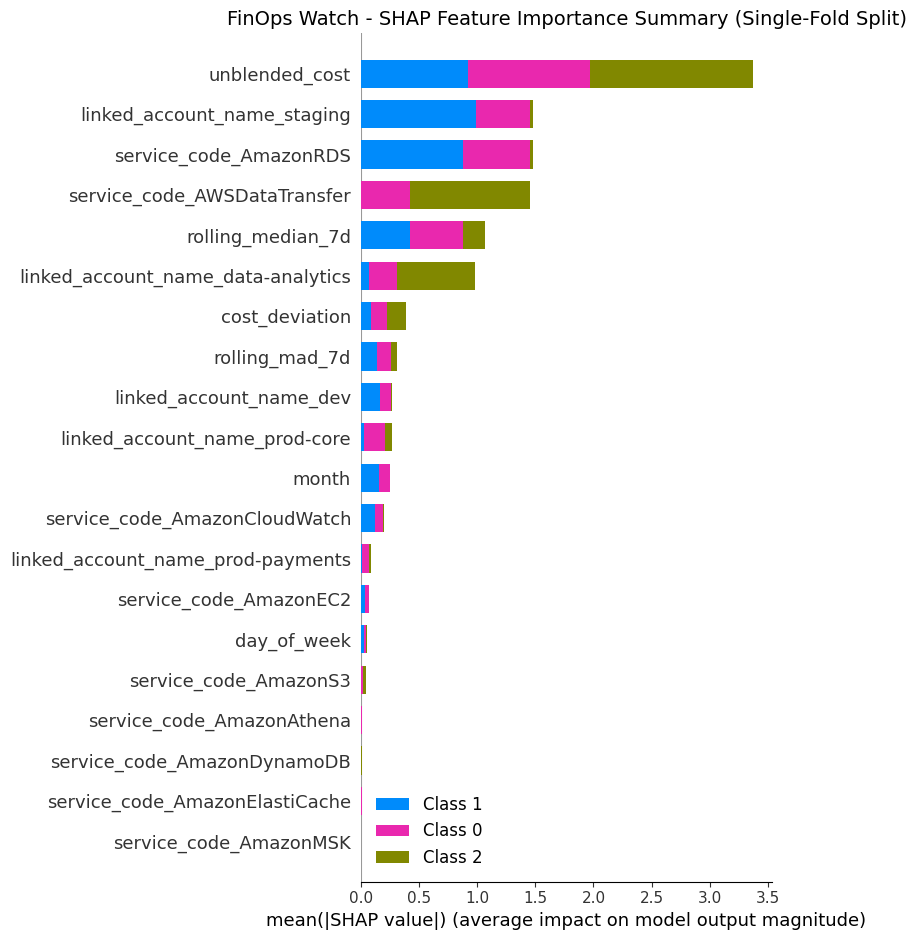

In [28]:
print("==================== ĐÁNH GIÁ SỰ ẢNH HƯỞNG ĐẶC TRƯNG BẰNG SHAP VALUE ====================")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

if isinstance(shap_values, list):
    mean_shap_features = np.mean([np.mean(np.abs(c_shap), axis=0) for c_shap in shap_values], axis=0)
else:
    mean_shap_features = np.mean(np.mean(np.abs(shap_values), axis=0), axis=1) if len(shap_values.shape) == 3 else np.mean(np.abs(shap_values), axis=0)

df_shap_ranking = pd.DataFrame({
    'Feature_Name': features,
    'SHAP_Importance_Score': mean_shap_features
}).sort_values(by='SHAP_Importance_Score', ascending=False).reset_index(drop=True)

print("\n[BẢNG XẾP HẠNG TOP ĐẶC TRƯNG QUAN TRỌNG NHẤT HỆ THỐNG]:")
print(df_shap_ranking.head(10))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type="bar", show=False)
plt.title("FinOps Watch - SHAP Feature Importance Summary (Single-Fold Split)", fontsize=14)
plt.tight_layout()
plt.show()